# Procesamiento Digital de Imágenes
## Práctica 0 — Introducción a Python y OpenCV
**FICH, UNL — Ingeniería Informática**

In [ ]:
# Instalación de dependencias (correr solo si falta alguna)
# !pip install opencv-python numpy matplotlib ipywidgets

In [1]:
# ── CELDA 1: Montar Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── CELDA 2: Ir a la carpeta del proyecto ─────────────────────────────────────
import os

ruta = '/content/drive/MyDrive/Practica PDI - Santiago Bargas/Practica 0'
os.chdir(ruta)

# Verificar que las imágenes están ahí
print("Archivos en la carpeta:")
for f in os.listdir(ruta):
    print(f" ·", f)

ModuleNotFoundError: No module named 'google'

---
## 2. Hello World
Carga, inspección y visualización básica de una imagen.

Dimensiones: (256, 512, 3)
Tipo de dato: uint8


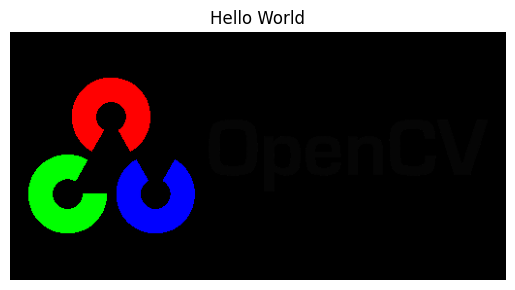

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('OpenCV-Logo.png')

print("Dimensiones:", imagen.shape)
print("Tipo de dato:", imagen.dtype)

plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Hello World')
plt.axis('off')
plt.show()

---
## 3. Creación, lectura y guardado
Generación de imágenes vacías, carga en escala de grises y guardado en disco.

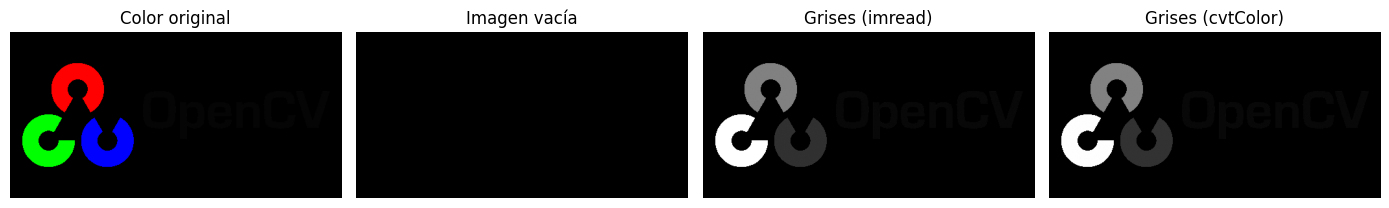

Imágenes guardadas.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen       = cv2.imread('OpenCV-Logo.png')
imagen_nueva = np.zeros(imagen.shape, dtype=imagen.dtype)
imagen_gray  = cv2.imread('OpenCV-Logo.png', cv2.IMREAD_GRAYSCALE)
imagen_gray3 = cv2.cvtColor(cv2.imread('OpenCV-Logo.png'), cv2.COLOR_BGR2GRAY)

titulos  = ['Color original', 'Imagen vacía', 'Grises (imread)', 'Grises (cvtColor)']
imagenes = [imagen, imagen_nueva, imagen_gray, imagen_gray3]
cmaps    = [None, None, 'gray', 'gray']

plt.figure(figsize=(14, 4))
for i, (img, titulo, cmap) in enumerate(zip(imagenes, titulos, cmaps)):
    plt.subplot(1, 4, i + 1)
    disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if cmap is None and img.ndim == 3 else img
    plt.imshow(disp, cmap=cmap)
    plt.title(titulo)
    plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('nueva_imagen.jpg',       imagen)
cv2.imwrite('nueva_imagen_vacia.jpg', imagen_nueva)
cv2.imwrite('nueva_imagen_gris.jpg',  imagen_gray)
cv2.imwrite('nueva_imagen_gris3.jpg', imagen_gray3)
print("Imágenes guardadas.")

---
## 4. Copiar, extraer ROIs y acceder al valor de un píxel

Dimensiones original : (256, 512, 3)
Dimensiones copia    : (256, 512, 3)
Dimensiones ROI      : (156, 200, 3)
Valor del píxel (150,150): [0 0 0]


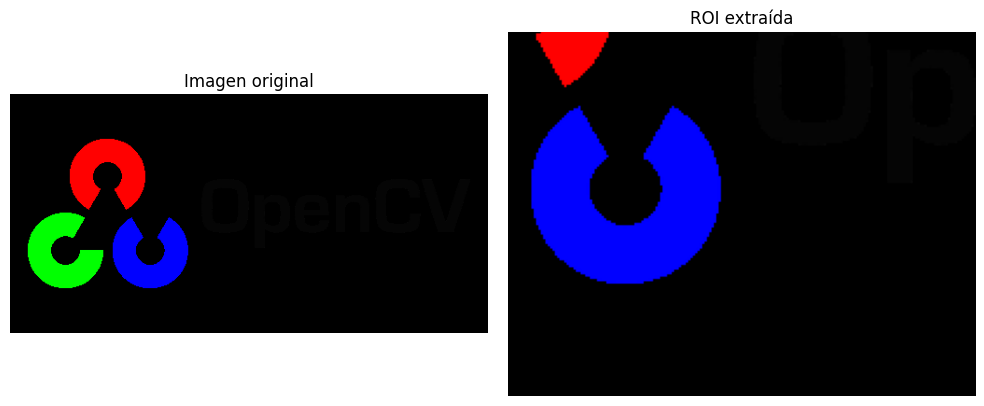

In [3]:
import cv2
import matplotlib.pyplot as plt

imagen  = cv2.imread('OpenCV-Logo.png')
imagen2 = imagen.copy()

x0, y0, x1, y1 = 100, 100, 300, 300
imagenRoi = imagen[x0:x1, y0:y1].copy()

y, x = 150, 150
valor_px = imagen[y, x]
print(f"Dimensiones original : {imagen.shape}")
print(f"Dimensiones copia    : {imagen2.shape}")
print(f"Dimensiones ROI      : {imagenRoi.shape}")
print(f"Valor del píxel ({x},{y}): {valor_px}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(imagenRoi, cv2.COLOR_BGR2RGB))
plt.title('ROI extraída')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 5. Herramientas para dibujar y visualizar
Primitivas geométricas y visualización con `matplotlib`.

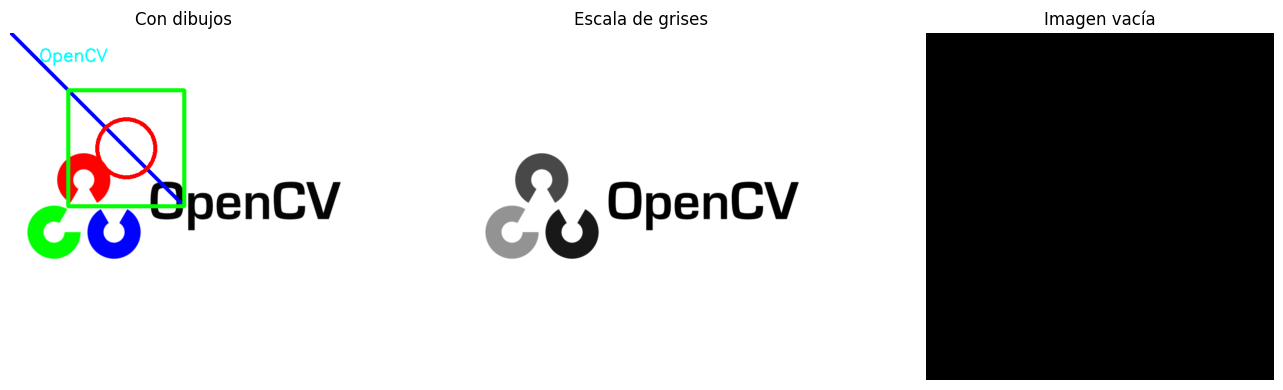

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen      = cv2.imread('OpenCV-Logo2.png')
imagen_gray = cv2.imread('OpenCV-Logo2.png', cv2.IMREAD_GRAYSCALE)
imagen2     = np.zeros(imagen.shape, dtype=imagen.dtype)

cv2.line(imagen,      (0, 0),     (300, 300), (255, 0,   0), 5)
cv2.rectangle(imagen, (100, 100), (300, 300), (0,   255, 0), 5)
cv2.circle(imagen,    (200, 200), 50,         (0,   0, 255), 5)
cv2.putText(imagen, 'OpenCV', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Con dibujos')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(imagen_gray, cmap='gray')
plt.title('Escala de grises')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imagen2)
plt.title('Imagen vacía')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 6. Avanzados

### 6.1 Eventos del mouse — dibujar líneas con click

In [18]:
%matplotlib widget

import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Cargar la imagen o crear una negra si no existe
imagen_base = cv2.imread('OpenCV-Logo.png')
if imagen_base is None:
    imagen_base = np.zeros((500, 500, 3), dtype='uint8')

# Variables globales
imagen_rgb = cv2.cvtColor(imagen_base, cv2.COLOR_BGR2RGB).copy()
puntos = []

# 1. Crear la figura UNA SOLA VEZ
fig, ax = plt.subplots(figsize=(6, 5))
# Guardamos la referencia de la imagen mostrada para actualizarla después
img_display = ax.imshow(imagen_rgb)
ax.set_title('Click para agregar puntos (línea cada 2 clicks)', fontsize=9)
ax.axis('off')

# 2. Función de captura de clicks
def on_click(event):
    # Ignorar clicks fuera de la imagen
    if event.xdata is None or event.ydata is None:
        return
    
    # Guardar punto
    puntos.append((int(event.xdata), int(event.ydata)))
    
    # (Opcional) Dibujar un puntito rojo para dar feedback del click
    cv2.circle(imagen_rgb, puntos[-1], 3, (255, 0, 0), -1)
    
    # Dibujar la línea si hay 2 o más puntos
    if len(puntos) >= 2:
        cv2.line(imagen_rgb, puntos[-2], puntos[-1], (0, 255, 0), 2)
    
    # 3. ACTUALIZAR la imagen en lugar de recrear la figura
    img_display.set_data(imagen_rgb)
    fig.canvas.draw_idle()

# Conectar el evento
fig.canvas.mpl_connect('button_press_event', on_click)

# 4. Botón de Reset
btn_reset = widgets.Button(description='Resetear imagen', button_style='warning')

def resetear(_):
    global imagen_rgb
    imagen_rgb = cv2.cvtColor(imagen_base, cv2.COLOR_BGR2RGB).copy()
    puntos.clear()
    
    # Actualizar la imagen gráfica al estado original
    img_display.set_data(imagen_rgb)
    fig.canvas.draw_idle()

btn_reset.on_click(resetear)

# Mostrar el botón y el gráfico
display(btn_reset)
plt.tight_layout()
plt.show()

RuntimeError: 'widget' is not a recognised GUI loop or backend name

### 6.2 Trackbar — blending de imágenes

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

imagen1 = cv2.imread('OpenCV-Logo.png')
if imagen1 is None:
    imagen1 = np.zeros((500, 500, 3), dtype='uint8')
imagen2 = np.full(imagen1.shape, 255, dtype='uint8')

slider = widgets.IntSlider(
    value=50, min=0, max=100, step=1,
    description='Alpha %:',
    continuous_update=False,
    layout=widgets.Layout(width='400px')
)
out = widgets.Output()

def actualizar(change):
    alpha = slider.value / 100
    beta  = 1.0 - alpha
    dst   = cv2.addWeighted(imagen1, alpha, imagen2, beta, 0.0)
    with out:
        clear_output(wait=True)
        plt.figure(figsize=(5, 4))
        plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
        plt.title(f'Blending — alpha={alpha:.2f}  beta={beta:.2f}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

slider.observe(actualizar, names='value')
display(slider, out)
actualizar(None)

IntSlider(value=50, continuous_update=False, description='Alpha %:', layout=Layout(width='400px'))

Output()

### 6.3 Pasaje de parámetros


In [ ]:
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

txt_gris  = widgets.Text(value='OpenCV-Logo.png',  description='Gris:',  layout=widgets.Layout(width='350px'))
txt_color = widgets.Text(value='OpenCV-Logo2.png', description='Color:', layout=widgets.Layout(width='350px'))
btn       = widgets.Button(description='Cargar', button_style='primary')
out       = widgets.Output()

def cargar(_):
    with out:
        clear_output(wait=True)
        img_gris  = cv2.imread(txt_gris.value,  cv2.IMREAD_GRAYSCALE)
        img_color = cv2.imread(txt_color.value)
        if img_gris is None or img_color is None:
            print('Error: no se encontraron los archivos. Verificá los nombres.')
            return
        print(f"Gris  → {txt_gris.value}  | shape: {img_gris.shape}")
        print(f"Color → {txt_color.value} | shape: {img_color.shape}")
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Color')
        axes[0].axis('off')
        axes[1].imshow(img_gris, cmap='gray')
        axes[1].set_title('Grises')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

btn.on_click(cargar)
display(widgets.VBox([txt_gris, txt_color, btn, out]))